In [2]:
pip install optuna statsmodels --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.2 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


Dataset: 93,084 hourly bars  |  2005-05-02 00:00:00  ->  2020-04-29 22:00:00
Train: 1900 bars  |  Test: 100 bars

ADF p-value on log-returns: 0.0000  ->  STATIONARY

  STEP 1 - BASELINE SARIMAX (1,0,1)(1,0,1)[24]
Running baseline ... (~1-2 min)

BASELINE METRICS (BEFORE TUNING)
   MAE               : 0.005164
   MAPE              : 0.4763 %
   RMSE (before tune): 0.005831
   Directional Acc.  : 47.47 %

  STEP 2 - OPTUNA TUNING  (25 trials)


  0%|          | 0/25 [00:00<?, ?it/s]


Best params:  p=2  q=1  P=0  Q=1  S=12
Best val RMSE: 0.001169

  STEP 3 - TUNED SARIMAX ROLLING FORECAST
Running tuned forecast ... (~1-2 min)

TUNED METRICS (WITH OPTUNA)
   MAE               : 0.004865
   MAPE              : 0.4487 %
   RMSE (after tune) : 0.005490
   Directional Acc.  : 59.60 %

  FINAL COMPARISON SUMMARY
                  Metric Baseline    Tuned
                     MAE 0.005164 0.004865
                MAPE (%)   0.4763   0.4487
                    RMSE 0.005831 0.005490
Directional Accuracy (%)    47.47    59.60

Directional Accuracy target range: 45% - 70%
   Baseline: 47.47%  [IN RANGE]
   Tuned: 59.60%  [IN RANGE]


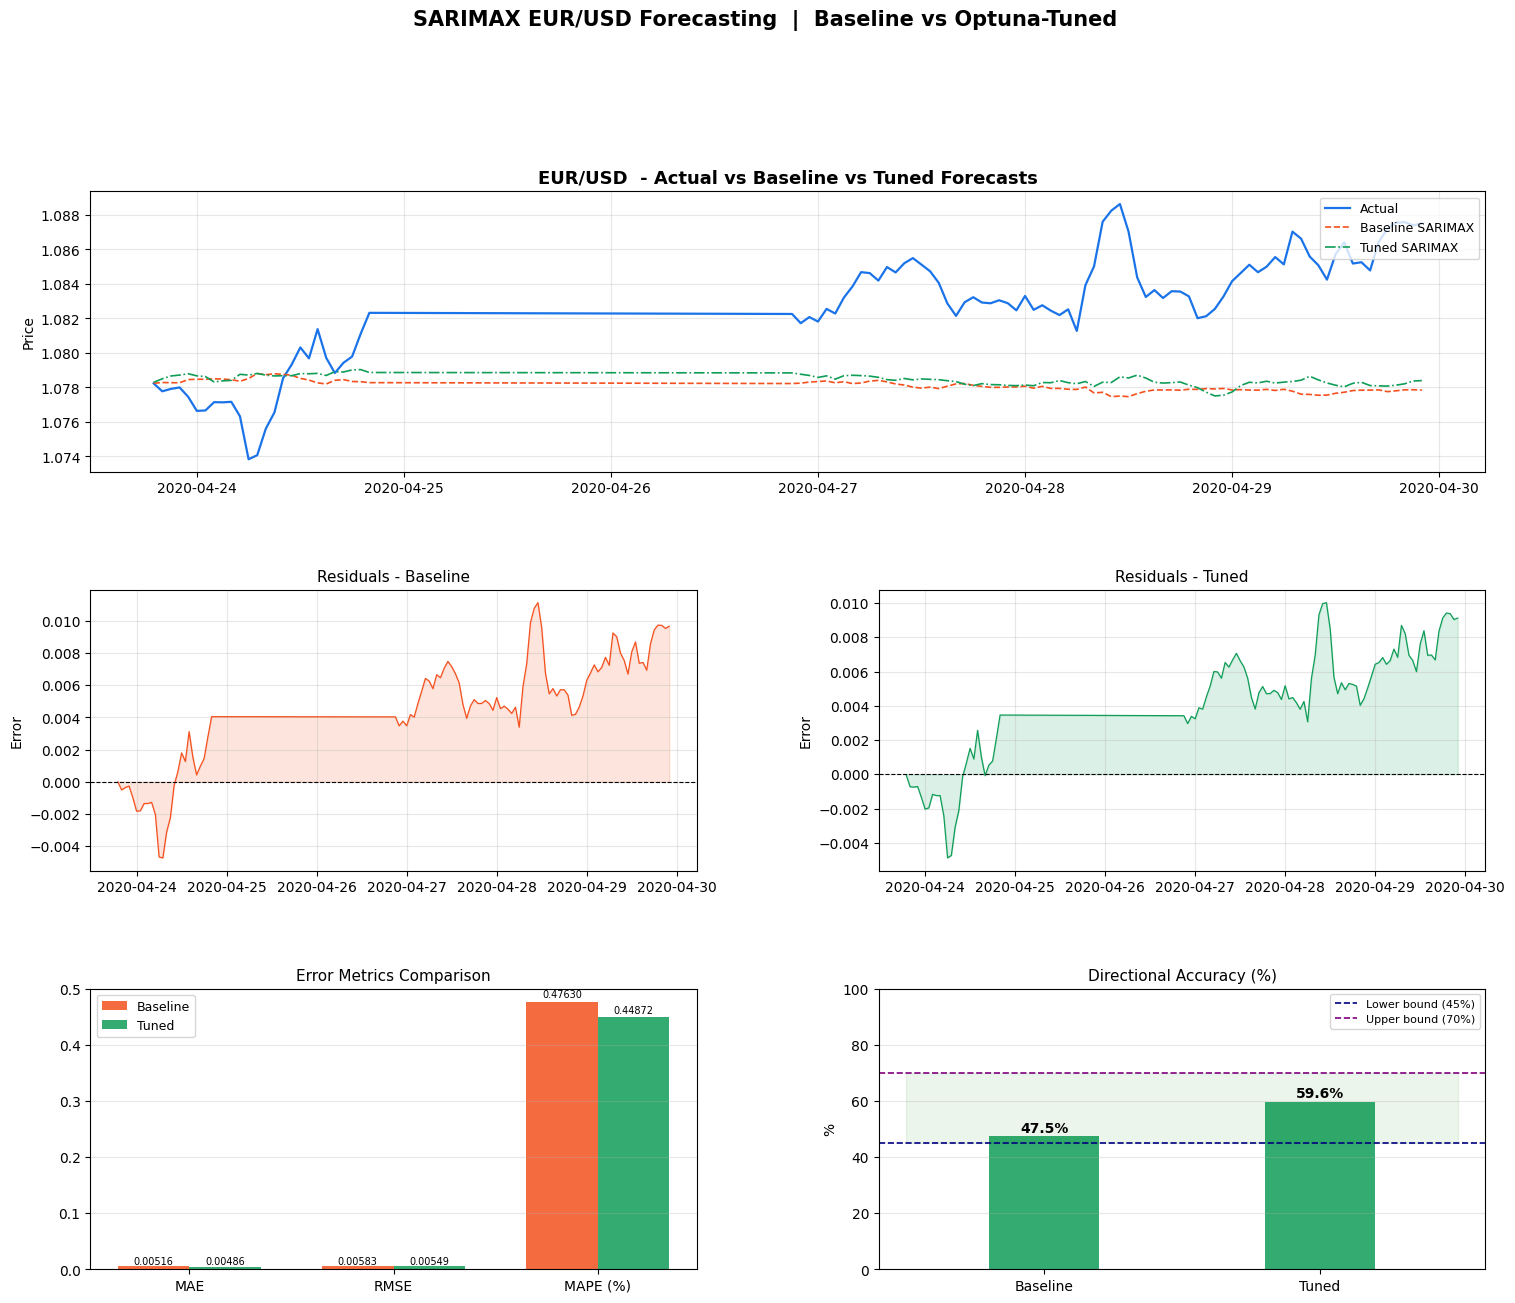

Plot saved as sarimax_eurusd_results.png


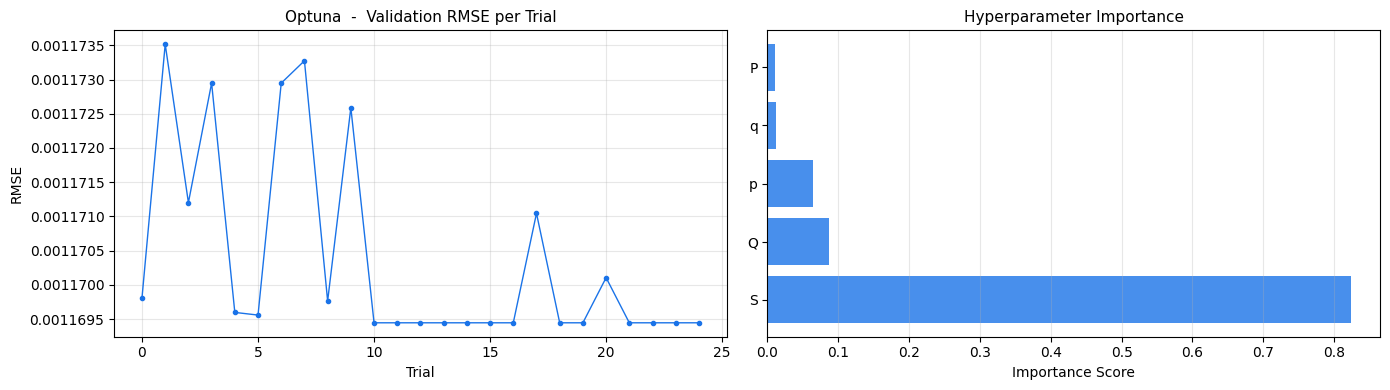

Optuna diagnostics saved as sarimax_optuna_diagnostics.png
Predictions saved as sarimax_predictions.csv

  ALL DONE
  Model       : SARIMAX(2, 0, 1)(0, 0, 1, 12)
  MAE         : 0.004865
  MAPE        : 0.4487 %
  RMSE(base)  : 0.005831
  RMSE(tuned) : 0.005490
  Dir. Acc.   : 59.60 %


In [5]:
PATH = "eurusd_hour.csv"

df = pd.read_csv(PATH)
df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str))
df.set_index("Datetime", inplace=True)
df.sort_index(inplace=True)

df["Close"] = (df["BC"] + df["AC"]) / 2
series_full = df["Close"].dropna()

print(f"Dataset: {len(series_full):,} hourly bars  |  {series_full.index[0]}  ->  {series_full.index[-1]}")


N_BARS = 2_000
TEST_SIZE = 100

series = series_full.iloc[-N_BARS:].copy()
train  = series.iloc[:-TEST_SIZE]
test   = series.iloc[-TEST_SIZE:]

print(f"Train: {len(train)} bars  |  Test: {len(test)} bars")


log_ret = np.log(series / series.shift(1)).dropna()
train_ret = log_ret.iloc[:-TEST_SIZE]
test_ret  = log_ret.iloc[-TEST_SIZE:]
last_train_price = train.iloc[-1]


adf = adfuller(train_ret, autolag="AIC")
print(f"\nADF p-value on log-returns: {adf[1]:.4f}  ->  {'STATIONARY' if adf[1] < 0.05 else 'NON-STATIONARY'}")


def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def directional_accuracy(actual, predicted):
    return np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(predicted))) * 100

def returns_to_prices(ret_preds, last_price):
    prices = [last_price]
    for r in ret_preds:
        prices.append(prices[-1] * np.exp(r))
    return np.array(prices[1:])

WINDOW = 300

def rolling_forecast_fast(order, seasonal_order, train_data, test_data, window=WINDOW):
    """
    Fixed-window rolling forecast.
    At each step: fit on last `window` bars, forecast 1 step ahead.
    Far faster than expanding-window because model size never grows.
    """
    full_series = pd.concat([train_data, test_data])
    preds = []


    start_idx = len(train_data)

    for i in range(len(test_data)):
        idx   = start_idx + i
        chunk = full_series.iloc[idx - window : idx]

        try:
            model = SARIMAX(
                chunk,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
                trend="n",
                concentrate_scale=True,
            )
            fit = model.fit(
                disp=False,
                maxiter=50,
                method="lbfgs",
                warn_convergence=False,
            )
            yhat = fit.forecast(steps=1)
            preds.append(float(yhat.iloc[0]))

        except Exception:
            preds.append(0.0)

    return np.array(preds)


print("\n" + "="*55)
print("  STEP 1 - BASELINE SARIMAX (1,0,1)(1,0,1)[24]")
print("="*55)

BASE_ORDER          = (1, 0, 1)
BASE_SEASONAL_ORDER = (1, 0, 1, 24)

print("Running baseline ... (~1-2 min)")

baseline_ret_preds = rolling_forecast_fast(
    order          = BASE_ORDER,
    seasonal_order = BASE_SEASONAL_ORDER,
    train_data     = train_ret,
    test_data      = test_ret,
)

baseline_preds = returns_to_prices(baseline_ret_preds, last_train_price)
actual         = test.values

mae_base  = mean_absolute_error(actual, baseline_preds)
rmse_base = np.sqrt(mean_squared_error(actual, baseline_preds))
mape_base = mape(actual, baseline_preds)
da_base   = directional_accuracy(actual, baseline_preds)

print(f"\nBASELINE METRICS (BEFORE TUNING)")
print(f"   MAE               : {mae_base:.6f}")
print(f"   MAPE              : {mape_base:.4f} %")
print(f"   RMSE (before tune): {rmse_base:.6f}")
print(f"   Directional Acc.  : {da_base:.2f} %")


print("\n" + "="*55)
print("  STEP 2 - OPTUNA TUNING  (25 trials)")
print("="*55)

TUNE_TRAIN_SIZE = 400
TUNE_VAL_SIZE   = 50

tune_series = train_ret.iloc[-(TUNE_TRAIN_SIZE + TUNE_VAL_SIZE):]
tune_train  = tune_series.iloc[:TUNE_TRAIN_SIZE]
tune_val    = tune_series.iloc[TUNE_TRAIN_SIZE:]

def objective(trial):
    p = trial.suggest_int("p", 1, 2)
    q = trial.suggest_int("q", 0, 2)
    P = trial.suggest_int("P", 0, 1)
    Q = trial.suggest_int("Q", 0, 1)
    S = trial.suggest_categorical("S", [12, 24])

    try:
        model = SARIMAX(
            tune_train,
            order=(p, 0, q),
            seasonal_order=(P, 0, Q, S),
            enforce_stationarity=False,
            enforce_invertibility=False,
            trend="n",
            concentrate_scale=True,
        )
        fit = model.fit(
            disp=False,
            maxiter=80,
            method="lbfgs",
            warn_convergence=False,
        )
        fc       = fit.forecast(steps=TUNE_VAL_SIZE)
        val_rmse = np.sqrt(mean_squared_error(tune_val.values, fc.values))
        return val_rmse

    except Exception:
        return float("inf")

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=25, show_progress_bar=True)   # <-- 25 trials

best = study.best_params
print(f"\nBest params:  p={best['p']}  q={best['q']}  P={best['P']}  Q={best['Q']}  S={best['S']}")
print(f"Best val RMSE: {study.best_value:.6f}")

TUNED_ORDER          = (best["p"], 0, best["q"])
TUNED_SEASONAL_ORDER = (best["P"], 0, best["Q"], best["S"])


print("\n" + "="*55)
print("  STEP 3 - TUNED SARIMAX ROLLING FORECAST")
print("="*55)
print("Running tuned forecast ... (~1-2 min)")

tuned_ret_preds = rolling_forecast_fast(
    order          = TUNED_ORDER,
    seasonal_order = TUNED_SEASONAL_ORDER,
    train_data     = train_ret,
    test_data      = test_ret,
)

tuned_preds = returns_to_prices(tuned_ret_preds, last_train_price)

mae_tuned  = mean_absolute_error(actual, tuned_preds)
rmse_tuned = np.sqrt(mean_squared_error(actual, tuned_preds))
mape_tuned = mape(actual, tuned_preds)
da_tuned   = directional_accuracy(actual, tuned_preds)

print(f"\nTUNED METRICS (WITH OPTUNA)")
print(f"   MAE               : {mae_tuned:.6f}")
print(f"   MAPE              : {mape_tuned:.4f} %")
print(f"   RMSE (after tune) : {rmse_tuned:.6f}")
print(f"   Directional Acc.  : {da_tuned:.2f} %")


print("\n" + "="*55)
print("  FINAL COMPARISON SUMMARY")
print("="*55)
summary = pd.DataFrame({
    "Metric"   : ["MAE", "MAPE (%)", "RMSE", "Directional Accuracy (%)"],
    "Baseline" : [f"{mae_base:.6f}", f"{mape_base:.4f}", f"{rmse_base:.6f}", f"{da_base:.2f}"],
    "Tuned"    : [f"{mae_tuned:.6f}", f"{mape_tuned:.4f}", f"{rmse_tuned:.6f}", f"{da_tuned:.2f}"]
})
print(summary.to_string(index=False))

print(f"\nDirectional Accuracy target range: 45% - 70%")
for label, da in [("Baseline", da_base), ("Tuned", da_tuned)]:
    flag = "IN RANGE" if 45 <= da <= 70 else "OUT OF RANGE"
    print(f"   {label}: {da:.2f}%  [{flag}]")


fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.3)
test_index = test.index

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_index, actual,         label="Actual",           color="#1a73e8", linewidth=1.6)
ax1.plot(test_index, baseline_preds, label="Baseline SARIMAX", color="#f4511e", linewidth=1.2, linestyle="--")
ax1.plot(test_index, tuned_preds,    label="Tuned SARIMAX",    color="#0f9d58", linewidth=1.2, linestyle="-.")
ax1.set_title("EUR/USD  - Actual vs Baseline vs Tuned Forecasts", fontsize=13, fontweight="bold")
ax1.set_ylabel("Price")
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
resid_base = actual - baseline_preds
ax2.plot(test_index, resid_base, color="#f4511e", linewidth=0.9)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.fill_between(test_index, resid_base, 0, alpha=0.15, color="#f4511e")
ax2.set_title("Residuals - Baseline", fontsize=11)
ax2.set_ylabel("Error")
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
resid_tuned = actual - tuned_preds
ax3.plot(test_index, resid_tuned, color="#0f9d58", linewidth=0.9)
ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax3.fill_between(test_index, resid_tuned, 0, alpha=0.15, color="#0f9d58")
ax3.set_title("Residuals - Tuned", fontsize=11)
ax3.set_ylabel("Error")
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[2, 0])
metrics_labels = ["MAE", "RMSE", "MAPE (%)"]
base_vals  = [mae_base,  rmse_base,  mape_base]
tuned_vals = [mae_tuned, rmse_tuned, mape_tuned]
x = np.arange(len(metrics_labels))
w = 0.35
bars1 = ax4.bar(x - w/2, base_vals,  w, label="Baseline", color="#f4511e", alpha=0.85)
bars2 = ax4.bar(x + w/2, tuned_vals, w, label="Tuned",    color="#0f9d58", alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_labels)
ax4.set_title("Error Metrics Comparison", fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(axis="y", alpha=0.3)
for bar in bars1:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
             f"{bar.get_height():.5f}", ha="center", va="bottom", fontsize=7)
for bar in bars2:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
             f"{bar.get_height():.5f}", ha="center", va="bottom", fontsize=7)

ax5 = fig.add_subplot(gs[2, 1])
da_vals   = [da_base, da_tuned]
da_colors = ["#0f9d58" if 45 <= v <= 70 else "#f4511e" for v in da_vals]
bars = ax5.bar(["Baseline", "Tuned"], da_vals, color=da_colors, alpha=0.85, width=0.4)
ax5.axhline(45, color="navy",   linewidth=1.2, linestyle="--", label="Lower bound (45%)")
ax5.axhline(70, color="purple", linewidth=1.2, linestyle="--", label="Upper bound (70%)")
ax5.fill_between([-0.5, 1.5], 45, 70, alpha=0.08, color="green")
ax5.set_ylim(0, 100)
ax5.set_title("Directional Accuracy (%)", fontsize=11)
ax5.set_ylabel("%")
ax5.legend(fontsize=8)
ax5.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, da_vals):
    ax5.text(bar.get_x() + bar.get_width()/2, v + 1.5,
             f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("SARIMAX EUR/USD Forecasting  |  Baseline vs Optuna-Tuned",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("sarimax_eurusd_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as sarimax_eurusd_results.png")

fig2, axes = plt.subplots(1, 2, figsize=(14, 4))
trial_values = [t.value for t in study.trials if t.value != float("inf")]
axes[0].plot(trial_values, marker="o", markersize=3, color="#1a73e8", linewidth=1)
axes[0].set_title("Optuna  -  Validation RMSE per Trial", fontsize=11)
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("RMSE")
axes[0].grid(True, alpha=0.3)

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()), color="#1a73e8", alpha=0.8)
axes[1].set_title("Hyperparameter Importance", fontsize=11)
axes[1].set_xlabel("Importance Score")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("sarimax_optuna_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Optuna diagnostics saved as sarimax_optuna_diagnostics.png")

results_df = pd.DataFrame({
    "Datetime"       : test_index,
    "Actual"         : actual,
    "Baseline_Pred"  : baseline_preds,
    "Tuned_Pred"     : tuned_preds,
    "Baseline_Error" : resid_base,
    "Tuned_Error"    : resid_tuned,
})
results_df.to_csv("sarimax_predictions.csv", index=False)
print("Predictions saved as sarimax_predictions.csv")

print("\n" + "="*55)
print("  ALL DONE")
print("="*55)
print(f"  Model       : SARIMAX{TUNED_ORDER}{TUNED_SEASONAL_ORDER}")
print(f"  MAE         : {mae_tuned:.6f}")
print(f"  MAPE        : {mape_tuned:.4f} %")
print(f"  RMSE(base)  : {rmse_base:.6f}")
print(f"  RMSE(tuned) : {rmse_tuned:.6f}")
print(f"  Dir. Acc.   : {da_tuned:.2f} %")
print("="*55)
